In [15]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [4]:
dataset = pd.read_csv('weight_dataset.csv')
dataset['Height'] = dataset['Height'] * 2.54    
dataset['Weight'] = dataset['Weight'] * 0.453592

In [5]:
dataset.head()

,Gender,Height,Weight
0,Male,187.571423,109.720985
1,Male,174.706036,73.622732
2,Male,188.239668,96.497550
3,Male,182.196685,99.809504
4,Male,177.499761,93.598619


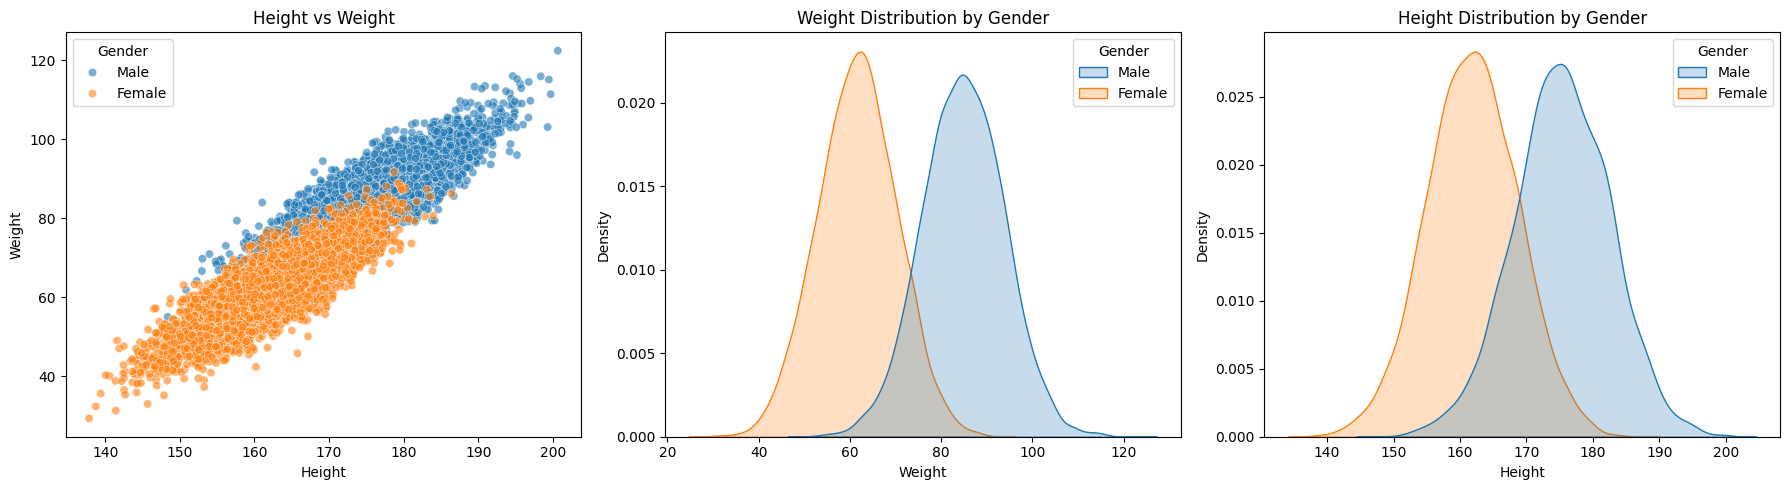

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(ax=axes[0], x='Height', y='Weight', hue='Gender', data=dataset, alpha=0.6)
axes[0].set_title('Height vs Weight')

sns.kdeplot(ax=axes[1], data=dataset, x='Weight', hue='Gender', fill=True)
axes[1].set_title('Weight Distribution by Gender')

sns.kdeplot(ax=axes[2], data=dataset, x='Height', hue='Gender', fill=True)
axes[2].set_title('Height Distribution by Gender')

plt.tight_layout()
plt.show()

In [9]:
X = dataset[['Gender', 'Height']]
y = dataset['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='first'), ['Gender'])
        ],
        remainder='passthrough'
    )

xgb_model = XGBRegressor(objective='reg:squarederror', random_state=101)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

In [10]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}


Mean Absolute Error (MAE): 3.74 kg
Root Mean Squared Error (RMSE): 4.65 kg
R2 Score: 0.8968


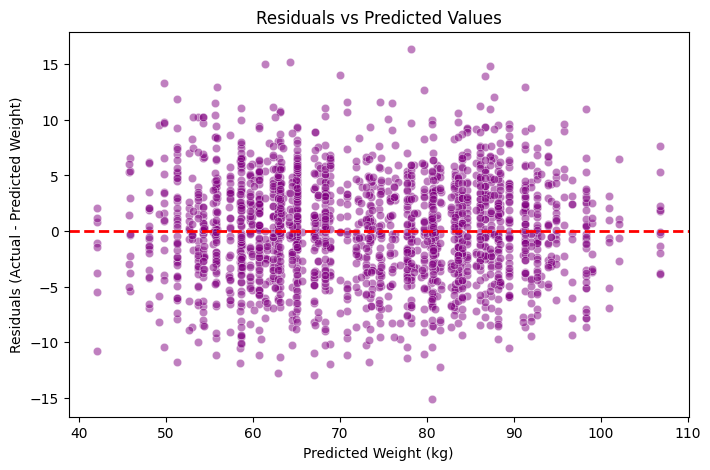

In [13]:
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} kg")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} kg")
print(f"R2 Score: {r2:.4f}")

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Weight (kg)')
plt.ylabel('Residuals (Actual - Predicted Weight)')
plt.show()

In [16]:
joblib.dump(best_model, 'weight_prediction_model.pkl')
print("Model saved successfully as 'weight_prediction_model.pkl'")

Model saved successfully as 'weight_prediction_model.pkl'
